Primeras filas:
   horas_sueno  actividad_fisica alimentacion  estres genero
0          7.2                 5      regular       7      M
1          6.3                 0      regular       8      M
2          7.5                 3    saludable       7      M
3          8.8                 2      regular       5      F
4          6.1                 0      regular       1      M

Descripción estadística:
       horas_sueno  actividad_fisica      estres
count   150.000000        150.000000  150.000000
mean      6.374000          2.946667    5.020000
std       1.413427          2.035875    2.638054
min       2.600000          0.000000    1.000000
25%       5.500000          1.000000    3.000000
50%       6.400000          3.000000    5.000000
75%       7.200000          5.000000    7.000000
max      10.200000          6.000000    9.000000


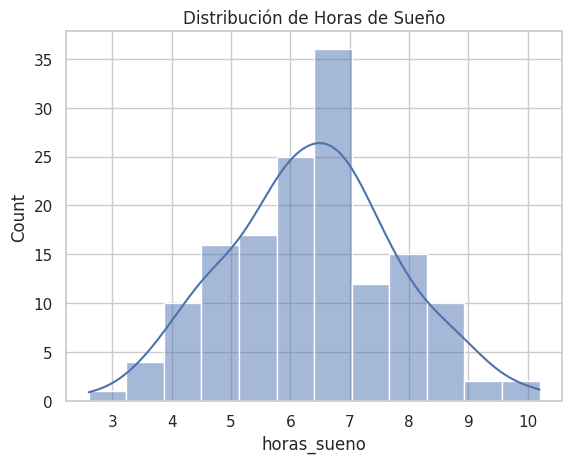

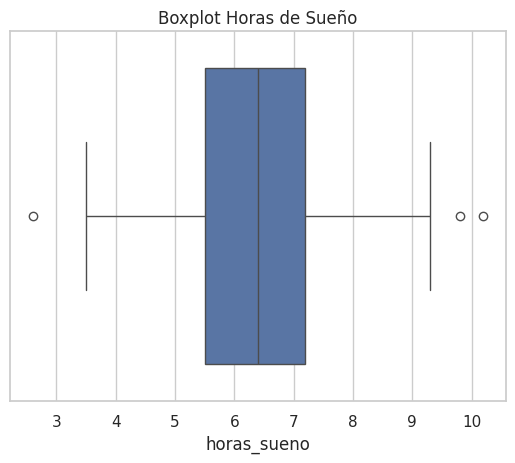


Probabilidad de dormir más de 7 horas: 0.27


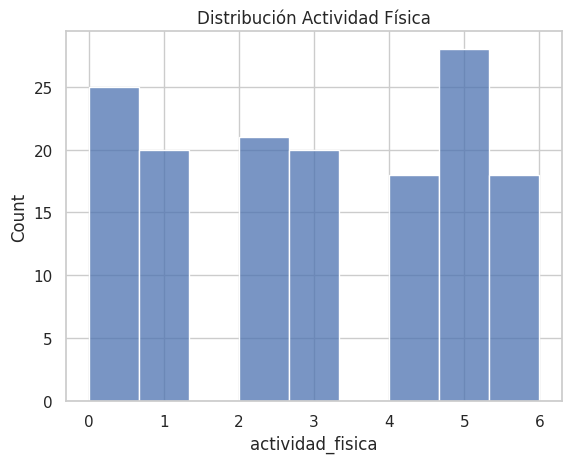

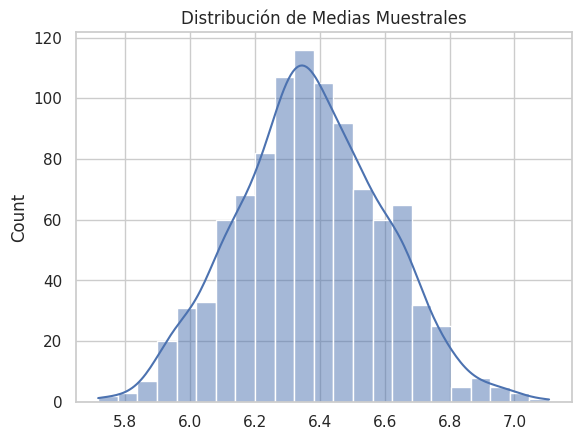


Intervalos de confianza:
90%: (np.float64(6.182986671344304), np.float64(6.565013328655695))
95%: (np.float64(6.14595655918307), np.float64(6.60204344081693))
99%: (np.float64(6.072879887738302), np.float64(6.675120112261697))

Matriz de correlación:
                  horas_sueno  actividad_fisica    estres
horas_sueno          1.000000         -0.057394  0.129556
actividad_fisica    -0.057394          1.000000 -0.059782
estres               0.129556         -0.059782  1.000000


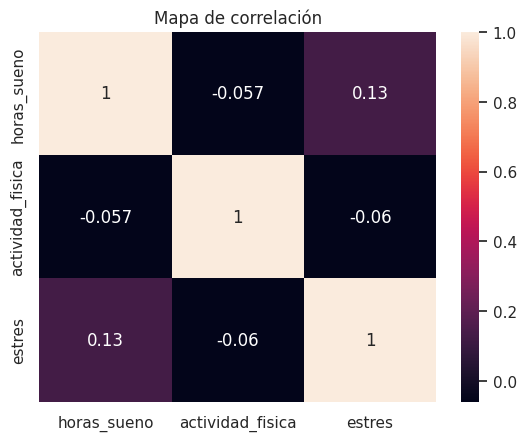

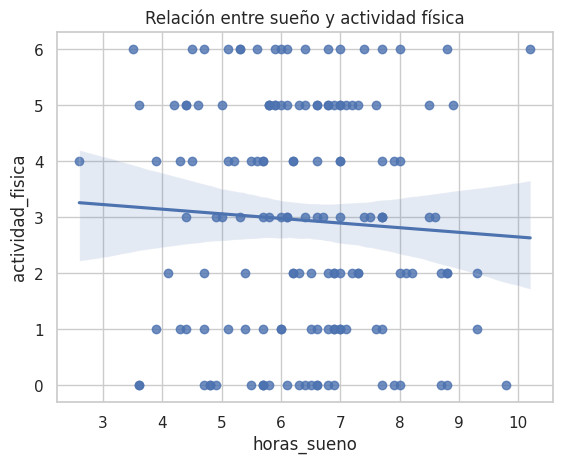


Test de hipótesis:
t-stat: -5.424336015961915
p-value: 2.2997978144275267e-07
Se rechaza la hipótesis nula

Dataset exportado correctamente


In [12]:
# =========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

# =========================================
# 2. GENERACIÓN DEL DATASET (SIMULACIÓN)
# =========================================
np.random.seed(42)
n = 150

df = pd.DataFrame({
    "horas_sueno": np.random.normal(6.5, 1.5, n).round(1),
    "actividad_fisica": np.random.randint(0, 7, n),
    "alimentacion": np.random.choice(["saludable", "regular", "mala"], n),
    "estres": np.random.randint(1, 10, n),
    "genero": np.random.choice(["M", "F"], n)
})

# Limpieza básica
df["horas_sueno"] = df["horas_sueno"].clip(0, 12)

print("Primeras filas:")
print(df.head())

# =========================================
# 3. ANÁLISIS EXPLORATORIO
# =========================================
print("\nDescripción estadística:")
print(df.describe())

# Histogramas
plt.figure()
sns.histplot(df["horas_sueno"], kde=True)
plt.title("Distribución de Horas de Sueño")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(x=df["horas_sueno"])
plt.title("Boxplot Horas de Sueño")
plt.show()

# =========================================
# 4. PROBABILIDAD
# =========================================
prob_mas_7 = (df["horas_sueno"] > 7).mean()
print(f"\nProbabilidad de dormir más de 7 horas: {prob_mas_7:.2f}")

# =========================================
# 5. DISTRIBUCIONES
# =========================================
plt.figure()
sns.histplot(df["actividad_fisica"], kde=False)
plt.title("Distribución Actividad Física")
plt.show()

# =========================================
# 6. TEOREMA DEL LÍMITE CENTRAL
# =========================================
medias = []

for i in range(1000):
    muestra = df["horas_sueno"].sample(30)
    medias.append(muestra.mean())

plt.figure()
sns.histplot(medias, kde=True)
plt.title("Distribución de Medias Muestrales")
plt.show()

# =========================================
# 7. INTERVALOS DE CONFIANZA
# =========================================
media = df["horas_sueno"].mean()
sem = stats.sem(df["horas_sueno"])

ic_90 = stats.t.interval(0.90, len(df)-1, loc=media, scale=sem)
ic_95 = stats.t.interval(0.95, len(df)-1, loc=media, scale=sem)
ic_99 = stats.t.interval(0.99, len(df)-1, loc=media, scale=sem)

print("\nIntervalos de confianza:")
print(f"90%: {ic_90}")
print(f"95%: {ic_95}")
print(f"99%: {ic_99}")

# =========================================
# 8. CORRELACIÓN
# =========================================
corr = df[["horas_sueno", "actividad_fisica", "estres"]].corr()
print("\nMatriz de correlación:")
print(corr)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Mapa de correlación")
plt.show()

# Scatterplot
plt.figure()
sns.regplot(x="horas_sueno", y="actividad_fisica", data=df)
plt.title("Relación entre sueño y actividad física")
plt.show()

# =========================================
# 9. TEST DE HIPÓTESIS
# =========================================
# H0: media = 7 horas
t_stat, p_val = stats.ttest_1samp(df["horas_sueno"], 7)

print("\nTest de hipótesis:")
print(f"t-stat: {t_stat}")
print(f"p-value: {p_val}")

alpha = 0.05
if p_val < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

# =========================================
# 10. EXPORTACIÓN
# =========================================
df.to_csv("dataset_habitos_saludables.csv", index=False)

print("\nDataset exportado correctamente")